In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/customer-support-dataset/customer_support_tickets.csv


## **Library 1**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.metrics import  accuracy_score,confusion_matrix,ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

## **1.Dataset Loading**

In [3]:
df=pd.read_csv("/kaggle/input/customer-support-dataset/customer_support_tickets.csv")

In [4]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

## **Classification Problem**

## **2.EDA**

## Null Values column wise

In [6]:
le=LabelEncoder()

In [7]:
for i in df.columns:
    print(f" Null Values for {i} is {df[i].isnull().sum()}")
    

 Null Values for Ticket ID is 0
 Null Values for Customer Name is 0
 Null Values for Customer Email is 0
 Null Values for Customer Age is 0
 Null Values for Customer Gender is 0
 Null Values for Product Purchased is 0
 Null Values for Date of Purchase is 0
 Null Values for Ticket Type is 0
 Null Values for Ticket Subject is 0
 Null Values for Ticket Description is 0
 Null Values for Ticket Status is 0
 Null Values for Resolution is 5700
 Null Values for Ticket Priority is 0
 Null Values for Ticket Channel is 0
 Null Values for First Response Time is 2819
 Null Values for Time to Resolution is 5700
 Null Values for Customer Satisfaction Rating is 5700


In [8]:
df['Customer Satisfaction Rating'].isnull().sum()

np.int64(5700)

In [9]:
df['Customer Satisfaction Rating'].value_counts()

Customer Satisfaction Rating
3.0    580
1.0    553
2.0    549
5.0    544
4.0    543
Name: count, dtype: int64

In [10]:
df['Ticket Type'].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

## Filling Zero(null) values

In [11]:
df = df.dropna(subset=['Customer Satisfaction Rating'])

In [12]:
df['Customer Satisfaction Rating'].value_counts()

Customer Satisfaction Rating
3.0    580
1.0    553
2.0    549
5.0    544
4.0    543
Name: count, dtype: int64

In [13]:
df['Customer Satisfaction Rating']=df['Customer Satisfaction Rating'].astype(int)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2769 entries, 2 to 8467
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Ticket ID                     2769 non-null   int64 
 1   Customer Name                 2769 non-null   object
 2   Customer Email                2769 non-null   object
 3   Customer Age                  2769 non-null   int64 
 4   Customer Gender               2769 non-null   object
 5   Product Purchased             2769 non-null   object
 6   Date of Purchase              2769 non-null   object
 7   Ticket Type                   2769 non-null   object
 8   Ticket Subject                2769 non-null   object
 9   Ticket Description            2769 non-null   object
 10  Ticket Status                 2769 non-null   object
 11  Resolution                    2769 non-null   object
 12  Ticket Priority               2769 non-null   object
 13  Ticket Channel         

In [15]:
X_unfiltered=df.drop(columns=['Ticket ID','Customer Name','Customer Email','Ticket Description','Resolution','Ticket Status','Ticket Subject','First Response Time','Time to Resolution','Customer Satisfaction Rating'])
y=df['Customer Satisfaction Rating']

In [16]:
y.value_counts()

Customer Satisfaction Rating
3    580
1    553
2    549
5    544
4    543
Name: count, dtype: int64

In [17]:
X_unfiltered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2769 entries, 2 to 8467
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Customer Age       2769 non-null   int64 
 1   Customer Gender    2769 non-null   object
 2   Product Purchased  2769 non-null   object
 3   Date of Purchase   2769 non-null   object
 4   Ticket Type        2769 non-null   object
 5   Ticket Priority    2769 non-null   object
 6   Ticket Channel     2769 non-null   object
dtypes: int64(1), object(6)
memory usage: 173.1+ KB


In [18]:
# Customer Gender,Ticket type,Ticket Priority,Ticket Channel

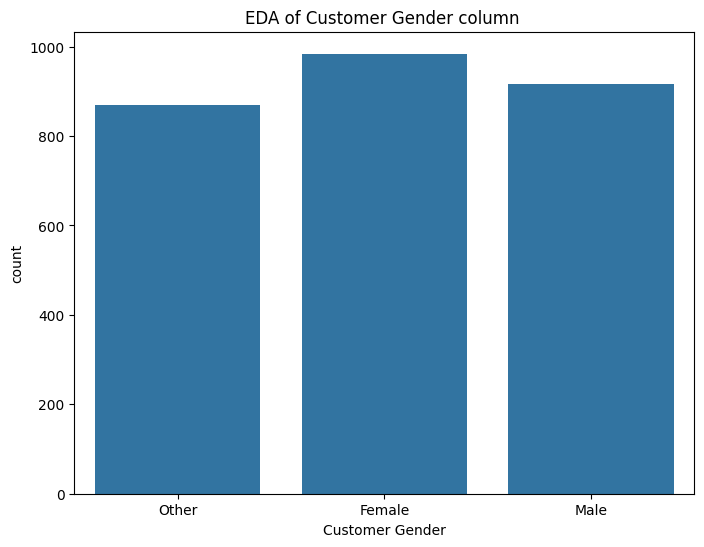

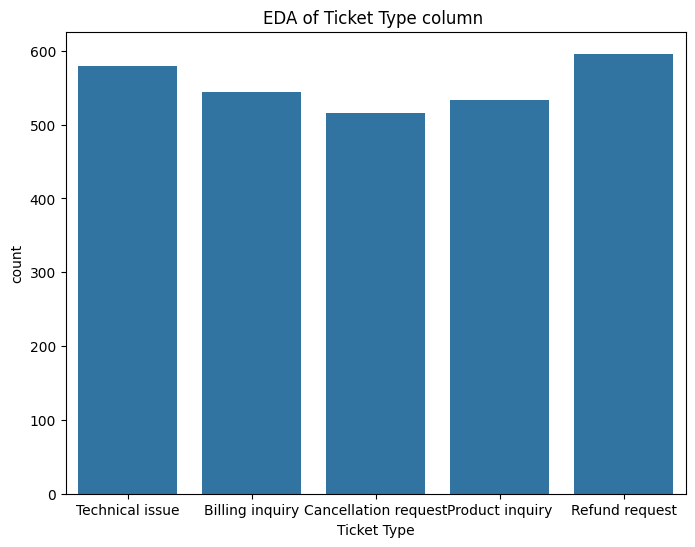

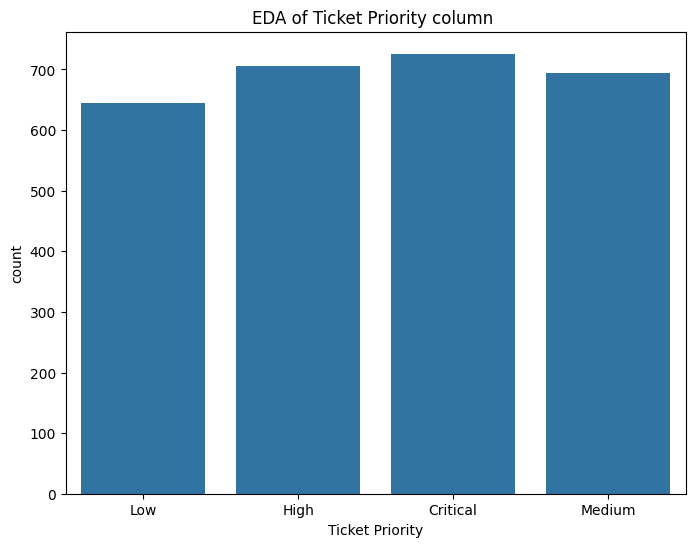

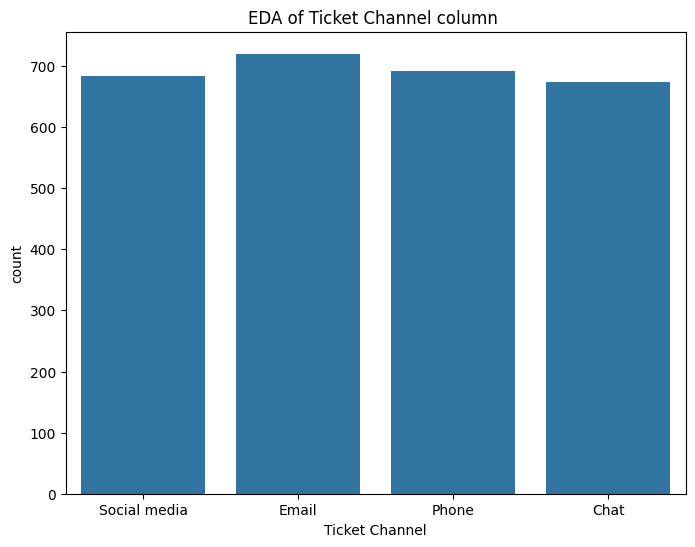

In [19]:
S=['Customer Gender','Ticket Type','Ticket Priority','Ticket Channel']

for i in S:

    plt.figure(figsize=(8,6))
    sns.countplot(x=i,data=X_unfiltered)
    plt.title(f'EDA of {i} column ')
    plt.show()


In [20]:
y

2       3
3       3
4       1
10      1
11      1
       ..
8452    3
8453    5
8455    1
8466    3
8467    3
Name: Customer Satisfaction Rating, Length: 2769, dtype: int64

In [21]:
y

2       3
3       3
4       1
10      1
11      1
       ..
8452    3
8453    5
8455    1
8466    3
8467    3
Name: Customer Satisfaction Rating, Length: 2769, dtype: int64

In [22]:
X_unfiltered.head()

,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Priority,Ticket Channel
2,48,Other,Dell XPS,2020-07-14,Technical issue,Low,Social media
3,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Low,Social media
4,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Low,Email
10,48,Male,Nintendo Switch,2021-01-19,Cancellation request,High,Phone
11,51,Male,Microsoft Xbox Controller,2021-10-24,Product inquiry,High,Chat


for i in X_unfiltered.columns:
    print(f" Unique Categories  for {i} is {X_unfiltered[i].value_counts()}")
    

X['Product Purchased'].value_counts()

## Cardinality balance 
top_products = df["Product Purchased"].value_counts().nlargest(10).index

df["Product Purchased"] = df["Product Purchased"].where(
    df["Product Purchased"].isin(top_products), "Other"
)

df = pd.get_dummies(df, columns=["Product Purchased"], drop_first=True)


## Encoding and Feature Engineering with respect to data type

In [23]:
X_unfiltered['Date of Purchase']=pd.to_datetime(X_unfiltered['Date of Purchase'])
X_unfiltered['Year']=X_unfiltered['Date of Purchase'].dt.year
X_unfiltered['Month']=X_unfiltered['Date of Purchase'].dt.month
X_unfiltered=X_unfiltered.drop(columns=['Date of Purchase'])

In [24]:
X_unfiltered.head(3)

,Customer Age,Customer Gender,Product Purchased,Ticket Type,Ticket Priority,Ticket Channel,Year,Month
2,48,Other,Dell XPS,Technical issue,Low,Social media,2020,7
3,27,Female,Microsoft Office,Billing inquiry,Low,Social media,2020,11
4,67,Female,Autodesk AutoCAD,Billing inquiry,Low,Email,2020,2


In [25]:
X_unfiltered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2769 entries, 2 to 8467
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Customer Age       2769 non-null   int64 
 1   Customer Gender    2769 non-null   object
 2   Product Purchased  2769 non-null   object
 3   Ticket Type        2769 non-null   object
 4   Ticket Priority    2769 non-null   object
 5   Ticket Channel     2769 non-null   object
 6   Year               2769 non-null   int32 
 7   Month              2769 non-null   int32 
dtypes: int32(2), int64(1), object(5)
memory usage: 173.1+ KB


## Filtering Data types

In [26]:
X_filtered=X_unfiltered.copy()

In [27]:
X_filtered.sample(3)

,Customer Age,Customer Gender,Product Purchased,Ticket Type,Ticket Priority,Ticket Channel,Year,Month
6749,64,Other,LG Washing Machine,Technical issue,Medium,Email,2021,1
1949,43,Other,HP Pavilion,Cancellation request,High,Chat,2021,9
3387,62,Male,GoPro Action Camera,Refund request,Critical,Chat,2020,6


In [28]:
y.head(3)

2    3
3    3
4    1
Name: Customer Satisfaction Rating, dtype: int64

## Distributing Categorical and Numerical Features

In [29]:
categorical_features=X_filtered.select_dtypes(include=['object']).columns
numerical_features=X_filtered.select_dtypes(include=['int64','int32']).columns

In [30]:
categorical_features

Index(['Customer Gender', 'Product Purchased', 'Ticket Type',
       'Ticket Priority', 'Ticket Channel'],
      dtype='object')

## Library 2

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay

In [32]:
preprocessor=ColumnTransformer(
    transformers=[
        ('one hot Encoding',OneHotEncoder(),categorical_features),
        ('Standard Scalers',StandardScaler(),numerical_features)
        
    ]
    
)

In [33]:
preprocessor

ColumnTransformer(transformers=[('one hot Encoding', OneHotEncoder(),
                                 Index(['Customer Gender', 'Product Purchased', 'Ticket Type',
       'Ticket Priority', 'Ticket Channel'],
      dtype='object')),
                                ('Standard Scalers', StandardScaler(),
                                 Index(['Customer Age', 'Year', 'Month'], dtype='object'))])

## **3. Model Train Test Split**

In [34]:
X_train,X_test,y_train,y_test=train_test_split(X_filtered,y,test_size=0.3,random_state=43)

In [35]:
X_train.shape

(1938, 8)

In [36]:
X_test.shape

(831, 8)

In [37]:
y_train.head(4)

4333    5
5147    2
7126    2
1483    2
Name: Customer Satisfaction Rating, dtype: int64

In [38]:
y_train.value_counts()

Customer Satisfaction Rating
3    407
4    390
2    387
1    385
5    369
Name: count, dtype: int64

In [39]:
le=LabelEncoder()
y_train=le.fit_transform(y_train)
y_test=le.transform(y_test)

In [40]:
y_train

array([4, 1, 1, ..., 4, 0, 3])

## Library 3

## Library Install
pip install xgboost

## Problems - 
Dataset (Class)is Imbalanced ,and it is multiclass Classification, so not relying on accuracy

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline

In [42]:
model_1={
    'Logistic Regression':
    LogisticRegression(max_iter=3000,solver='lbfgs',class_weight='balanced'),
    'KNN':KNeighborsClassifier(n_neighbors=17,weights='distance',metric='minkowski',n_jobs=-1),
    'Decision Trees':
    DecisionTreeClassifier(criterion='gini',max_depth=10,min_samples_split=18,min_samples_leaf=15,class_weight='balanced'),
    'Support Vector Machines':SVC(kernel='rbf',class_weight='balanced',probability=True,random_state=43),
    'Random Forest Classifier':
    RandomForestClassifier(n_estimators=300,random_state=43,class_weight='balanced',max_depth=5,min_samples_leaf=10,n_jobs=-1),
    'XGBoost':XGBClassifier(
        
        objective="multi:softprob",
        num_class=5,              # IMPORTANT for multiclass
        max_depth=6,
        n_estimators=400,
        learning_rate=0.1,
        subsample=0.8,            # correct spelling
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        random_state=43
    )
}

 'XGBoost':XGBClassifier(
        
        objective="multi:softprob",
        num_class=5,              # IMPORTANT for multiclass
        max_depth=6,
        n_estimators=400,
        learning_rate=0.1,
        subsample=0.8,            # correct spelling
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        random_state=43
    )
}

In [43]:
model_1.items()

dict_items([('Logistic Regression', LogisticRegression(class_weight='balanced', max_iter=3000)), ('KNN', KNeighborsClassifier(n_jobs=-1, n_neighbors=17, weights='distance')), ('Decision Trees', DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=15, min_samples_split=18)), ('Support Vector Machines', SVC(class_weight='balanced', probability=True, random_state=43)), ('Random Forest Classifier', RandomForestClassifier(class_weight='balanced', max_depth=5,
                       min_samples_leaf=10, n_estimators=300, n_jobs=-1,
                       random_state=43)), ('XGBoost', XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, im

In [44]:
results_1=[]
for model_name,models in model_1.items():
    
    print(f'The Model name is :{model_name}')
    pipeline=Pipeline(steps=[('preprocessing',preprocessor),
                             ('model',models) 
                            ]) 
    pipeline.fit(X_train,y_train) 
    y_pred=pipeline.predict(X_test) 
    f1=f1_score(y_test,y_pred,average='macro') 
    results_1.append(
        {'Model name':model_name, 'F1 Score':f1}
    )

The Model name is :Logistic Regression
The Model name is :KNN
The Model name is :Decision Trees
The Model name is :Support Vector Machines
The Model name is :Random Forest Classifier
The Model name is :XGBoost


In [45]:
results_1_df=pd.DataFrame(results_1).sort_values(by='F1 Score',ascending=False)

In [46]:
results_1_df

,Model name,F1 Score
0,Logistic Regression,0.193342
5,XGBoost,0.191780
4,Random Forest Classifier,0.184077
1,KNN,0.171954
3,Support Vector Machines,0.169871
2,Decision Trees,0.155332


## **4. HyperParameter Tuning**

In [47]:
param_grids={
    'Logistic Regression':(
        LogisticRegression(max_iter=3000,class_weight='balanced'),
        {
            'model__solver':['lbfgs','newton-cg','saga'],
            'model__C':np.logspace(-3,2,20)
        }
    ),
    'Random Forest Classifier':(
        RandomForestClassifier(random_state=43,n_jobs=-1),
        {
            'model__n_estimators':[200,300,400,500],
            'model__criterion':['gini','entropy'],
            'model__max_depth':[5,10,15,20],
            'model__min_samples_split':[2,4,6,8,10]
        }
    ),
    
    ' XG Boost Classifier':(
        XGBClassifier(objective="multi:softprob",random_state=43,
                     eval_metric="mlogloss",num_class=5),
        {
            "model__n_estimators": [200, 300, 400, 600],
            "model__max_depth": [3, 5, 7, 9],
            "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
            "model__subsample": [0.6, 0.8, 1.0],
            "model__colsample_bytree": [0.6, 0.8, 1.0]
        }
        )
    
}

In [48]:
param_grids.items()

dict_items([('Logistic Regression', (LogisticRegression(class_weight='balanced', max_iter=3000), {'model__solver': ['lbfgs', 'newton-cg', 'saga'], 'model__C': array([1.00000000e-03, 1.83298071e-03, 3.35981829e-03, 6.15848211e-03,
       1.12883789e-02, 2.06913808e-02, 3.79269019e-02, 6.95192796e-02,
       1.27427499e-01, 2.33572147e-01, 4.28133240e-01, 7.84759970e-01,
       1.43844989e+00, 2.63665090e+00, 4.83293024e+00, 8.85866790e+00,
       1.62377674e+01, 2.97635144e+01, 5.45559478e+01, 1.00000000e+02])})), ('Random Forest Classifier', (RandomForestClassifier(n_jobs=-1, random_state=43), {'model__n_estimators': [200, 300, 400, 500], 'model__criterion': ['gini', 'entropy'], 'model__max_depth': [5, 10, 15, 20], 'model__min_samples_split': [2, 4, 6, 8, 10]})), (' XG Boost Classifier', (XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,


In [49]:
tuned_results = []

for model_label, (model_obj, params) in param_grids.items():
    print(f"Model name is : {model_label}")

    pipeline_tuning = Pipeline(
        steps=[
            ('preprocessing',preprocessor),
            ('model',model_obj) 
                            ]
            ) 

    random_search = RandomizedSearchCV(
        estimator=pipeline_tuning,
        param_distributions=params,
        n_iter=15,
        scoring="f1_macro",
        cv=5,
        n_jobs=-1,
        random_state=43,
        verbose=1
    )
    random_search.fit(X_train,y_train)
    best_model=random_search.best_estimator_
    y_pred=best_model.predict(X_test)
    tuned_results.append(
        {
        "Model name": model_label,
        "Best CV F1_macro": random_search.best_score_,
        "Test F1_macro": f1_score(y_test, y_pred, average="macro"),
        "Best Parameters": random_search.best_params_
    }
    )
    

Model name is : Logistic Regression
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Model name is : Random Forest Classifier
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Model name is :  XG Boost Classifier
Fitting 5 folds for each of 15 candidates, totalling 75 fits


In [50]:
tuned_results_df=pd.DataFrame(tuned_results).sort_values(by='Best CV F1_macro',ascending=False)

In [51]:
tuned_results_df

,Model name,Best CV F1_macro,Test F1_macro,Best Parameters
0,Logistic Regression,0.215556,0.203357,"{'model__solver': 'lbfgs', 'model__C': 0.03792..."
1,Random Forest Classifier,0.211138,0.159312,"{'model__n_estimators': 200, 'model__min_sampl..."
2,XG Boost Classifier,0.207669,0.174333,"{'model__subsample': 0.8, 'model__n_estimators..."


In [52]:
pd.set_option('display.max_colwidth', 0)
tuned_results_df

,Model name,Best CV F1_macro,Test F1_macro,Best Parameters
0,Logistic Regression,0.215556,0.203357,"{'model__solver': 'lbfgs', 'model__C': 0.0379269019073225}"
1,Random Forest Classifier,0.211138,0.159312,"{'model__n_estimators': 200, 'model__min_samples_split': 8, 'model__max_depth': 20, 'model__criterion': 'entropy'}"
2,XG Boost Classifier,0.207669,0.174333,"{'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.2, 'model__colsample_bytree': 0.8}"
